# (10) metabolic cost pvae (CCN 2026) figs

project = ```P-VAE```, host = ```chewie```, device = ```cuda:1```

**Motivation**: <br>

Goal: `MetabolicCost`

In [1]:
# HIDE CODE


import os, pathlib
from IPython.display import display

# tmp & extras dir
_jb_dir = pathlib.Path(os.environ['HOME'])
_jb_dir /= 'Dropbox/git/jb-progress-2026'
extras_dir = _jb_dir / '_extras'
fig_base_dir = _jb_dir / 'figs'
tmp_dir = _jb_dir / 'tmp'

from mcfe.utils.plotting import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: chewie

## Fig setup

In [3]:
fig_dir = 'ccn2026_metabolic_cost'
fig_dir = fig_base_dir / fig_dir
fig_dir.mkdir(parents=True, exist_ok=True)

sorted(os.listdir(str(fig_dir)))

['dists_poisson_grelu.pdf',
 'portion_zeros.pdf',
 'portion_zeros_pie.pdf',
 'posterior_sample_means.pdf']

## Dist plots

In [441]:
pal = {'pois': 'C0', 'gaus-relu': 'C1'}


def plot_dists(figsize=(9, 3.2), add_labels=True):
    fig, axes = create_figure(nrows=1, ncols=2, figsize=figsize)
    # --- Left Plot: Poisson ---
    ax = axes[0]
    lamb = 2
    x_k = np.arange(0, 8)
    y_pmf = sp_stats.poisson.pmf(x_k, lamb)
    ax.vlines(x_k, 0, y_pmf, colors=pal['pois'], lw=1.5, alpha=0.7)
    ax.plot(x_k, y_pmf, 'o', color=pal['pois'], markersize=12, label=r'$\mathcal{P}$-VAE')
    ax.axhline(0, color='dimgrey', ls=':', lw=0.9)
    ax.legend(fontsize=17, frameon=True, loc='upper right')
    ax.set_ylim((-0.01, 0.31))
    ax.locator_params(nbins=4)
    
    # Param box for Poisson
    ax.text(0.95, 0.725, r'$\lambda \;\equiv\; \mathrm{rate} \;=\; 2$',
            transform=ax.transAxes, fontsize=14.5,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                      edgecolor='lightgrey', alpha=0.9))

    # --- Right Plot: Truncated Gaussian (ReLU) ---
    ax = axes[1]
    x_grid = np.linspace(-1.6, 5.2, 1000)
    y_pdf = sp_stats.norm.pdf(x_grid, loc=0, scale=1)
    ax.fill_between(x_grid, y_pdf, color='grey', alpha=0.07)
    ax.plot(x_grid, y_pdf, color='grey', alpha=0.7, linestyle='--', label=r'$\mathcal{G}$-VAE')
    y_relu = np.where(x_grid < 0, 0, y_pdf)
    ax.plot(x_grid, y_relu, color=pal['gaus-relu'], lw=4, label=r'$\mathcal{G}_\mathrm{relu}$-VAE')
    ax.legend(fontsize=17, frameon=True, loc='upper right')

    # Param box for Gaussian
    ax.text(0.954, 0.575, r'$\lambda \;\equiv\; (\mu,\,\sigma) \;=\; (0,\,1)$',
            transform=ax.transAxes, fontsize=13,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                      edgecolor='lightgrey', alpha=0.9))

    if add_labels:
        # axes[0].set_ylabel('Approx. posterior  ' + r'$q_{\lambda}(z)$', fontsize=14)
        axes[0].set_ylabel('Approx. posterior  ' + r'$q_{\lambda}(z \vert x)$', fontsize=14)
        axes[0].set_xlabel('Latent sample ' + r'$(z)$', fontsize=16)
        axes[1].set_xlabel('Latent sample ' + r'$(z)$', fontsize=16)
    plt.show()

    return fig

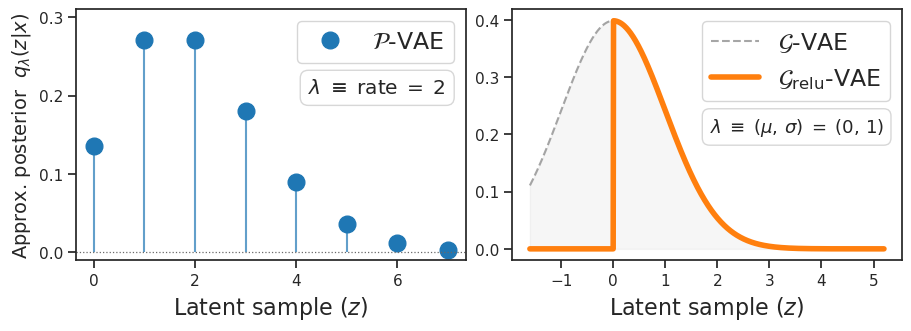

In [445]:
fig = plot_dists()

# fig.savefig(fig_dir / 'dists_poisson_grelu.pdf', bbox_inches='tight')    

## Results dir

In [7]:
results_sata_dir = '/mnt/sata/Hadi/Hadi_Results_Backup'
print(os.listdir(results_sata_dir))

['results_2025-08', 'results_2025-04', 'results_2025-03', 'results_2025-10', 'results_2025-07']

In [8]:
results_dir = pjoin(results_sata_dir, 'results_2025-10')
fits = [f for f in os.listdir(results_dir) if 'MetabolicCost' in f]
fits = sorted(fits, key=alphanum_sort_key)

len(fits)

176

## Load results

In [9]:
info_keys = ['str_model', 'n_latents', 'kl_beta']

df_metabolic_cost = collections.defaultdict(list)

for f in tqdm(fits):
    load = np.load(pjoin(results_dir, f), allow_pickle=True).item()
    info, results = load['info'], load['results']
    
    # info
    for k in info_keys:
        df_metabolic_cost[k].append(
            info.get(k, None))

    # results
    r2 = results['r2']
    portion_zeros = results['%-zeros']
    euc_dist = np.sqrt(
        (1 - r2) ** 2 +
        (1 - portion_zeros) ** 2
    )
    df_metabolic_cost['r2'].append(r2)
    df_metabolic_cost['portion_zeros'].append(portion_zeros)
    df_metabolic_cost['euc_dist'].append(euc_dist)

    df_metabolic_cost['lifetime'].append(results['lifetime'])
    df_metabolic_cost['samples_mean'].append(
        results['samples_final'].mean())
    df_metabolic_cost['posterior_mean'].append(
        results['posterior_mean'])

df_metabolic_cost = pd.DataFrame(df_metabolic_cost)

# normalize the euclidean dist
df_metabolic_cost['euc_dist'] /= np.sqrt(2)

  0%|          | 0/176 [00:00<?, ?it/s]

In [10]:
info

{'checkpoint': 3000,
 'timestamp': '2025_10_13,17:55',
 'seed': 0,
 'dataset': 'vH16',
 'type': 'poisson',
 'latent_act': None,
 'n_latents': 4096,
 'str_model': 'poisson+amort',
 'archi': '<lin|lin>',
 'seq_len': 1,
 'kl_beta': 8.0,
 'n_params': 2101248,
 'n_iters_train': 312000}

In [11]:
df_metabolic_cost

,str_model,n_latents,kl_beta,r2,portion_zeros,euc_dist,lifetime,samples_mean,posterior_mean
0,gaussian+relu+amort,32,0.10,0.258601,0.189858,0.776531,0.448035,1.109768,1.109621
1,gaussian+relu+amort,32,0.01,0.281405,0.081654,0.824542,0.378761,2.521186,2.521179
2,gaussian+relu+amort,64,0.10,0.443983,0.213069,0.681328,0.466705,1.037755,1.037621
3,gaussian+relu+amort,64,0.01,0.483163,0.088891,0.740689,0.385468,2.361963,2.361885
4,gaussian+relu+amort,128,0.01,0.732195,0.104071,0.661214,0.401691,2.054607,2.054527
...,...,...,...,...,...,...,...,...,...
171,poisson+amort,512,8.00,-0.010499,0.997947,0.714532,0.998013,0.119269,0.119245
172,poisson+amort,768,8.00,-0.010585,0.998614,0.714592,0.998667,0.079980,0.079971
173,poisson+amort,1024,8.00,-0.010606,0.998946,0.714607,0.998994,0.059709,0.059656
174,poisson+amort,2048,8.00,-0.010646,0.999461,0.714635,0.999495,0.029700,0.029713


In [12]:
sorted(df_metabolic_cost['n_latents'].unique())

[32, 64, 128, 192, 256, 384, 512, 768, 1024, 2048, 4096]

In [13]:
sorted(df_metabolic_cost['kl_beta'].unique())

[0.01, 0.1, 0.5, 1.0, 1.5, 2.0, 4.0, 8.0]

## plot figs

In [14]:
sorted(os.listdir(fig_dir))

['dists_poisson_grelu.pdf',
 'portion_zeros.pdf',
 'portion_zeros_pie.pdf',
 'posterior_sample_means.pdf']

In [15]:
pal = {'poisson': 'C0', 'gaussian-relu': 'C1'}
selected_k = [64, 128, 192, 256, 384, 512, 1024, 2048]

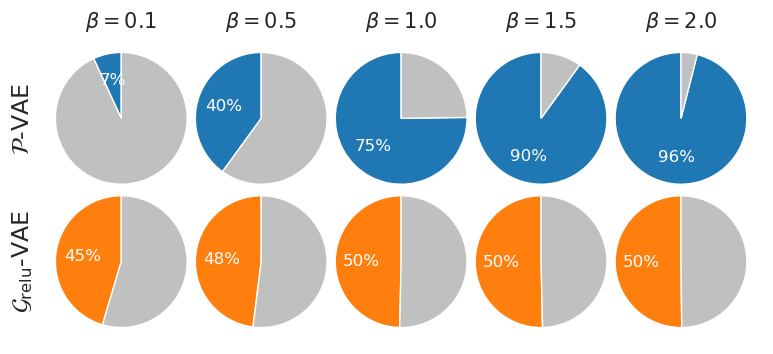

In [16]:
str_models = ['poisson+amort', 'gaussian+relu+amort']
kl_betas = [0.1, 0.5, 1.0, 1.5, 2.0]
n_latents = 512

fig, axes = create_figure(
    nrows=len(str_models),
    ncols=len(kl_betas),
    figsize=(10.0, 4.0),
    hspace=-0.13,
    wspace=-0.35,
    cnst=False,
)

for i, s in enumerate(str_models):
    for j, b in enumerate(kl_betas):
        data = df_metabolic_cost.loc[
            (df_metabolic_cost['kl_beta'] == b) &
            (df_metabolic_cost['str_model'] == s) &
            (df_metabolic_cost['n_latents'] == n_latents)
        ]

        # Extract data
        data = data.to_dict(orient='records')[0]
        pz = data['portion_zeros']
        sizes = [pz, 1 - pz]

        # Determine color
        key = data['str_model'].replace('+amort', '').replace('+', '-')
        color_main = pal[key]
        colors = [color_main, 'silver']

        ax = axes[i, j]
        
        # Capture the return values to modify text properties
        wedges, texts, autotexts = ax.pie(
            sizes, 
            colors=colors, 
            startangle=90, 
            autopct='%.0f%%'
        )
    
        # autotexts[0] is the percentage for the first slice (portion_zeros)
        autotexts[0].set_color('white')

        # autotexts[1] is the percentage for the remainder; hide it
        autotexts[1].set_visible(False)

        # Labels
        if i == 0:
            ax.set_title(f'$\\beta = {b}$', fontsize=15)
        if j == 0:
            text = (
                r'$\mathcal{P}$-VAE' if 'poisson' in s else
                r'$\mathcal{G}_\mathrm{relu}$-VAE'
            )
            ax.text(
                -0.1, 0.5, text, transform=ax.transAxes, 
                va='center', ha='center', fontsize=17, rotation=90)

fig.savefig(pjoin(fig_dir, 'portion_zeros_pie.pdf'), bbox_inches='tight')
plt.show()

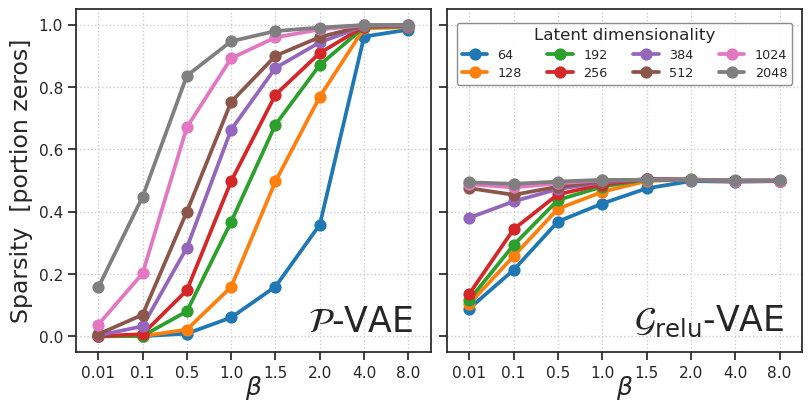

In [24]:
kws = dict(x='kl_beta', y='portion_zeros', hue='n_latents', palette='tab10', legend=False)


fig, axes = create_figure(1, 2, (8, 4), sharey='all')

kws['data'] = df_metabolic_cost.loc[
    (df_metabolic_cost['str_model'] == 'poisson+amort') &
    (df_metabolic_cost['n_latents'].isin(selected_k))
]
sns.pointplot(ax=axes[0], **kws)

kws['data'] = df_metabolic_cost.loc[
    (df_metabolic_cost['str_model'] == 'gaussian+relu+amort') &
    (df_metabolic_cost['n_latents'].isin(selected_k))
]
kws['legend'] = True
sns.pointplot(ax=axes[1], **kws)

# axes[0].set_title(r'$\mathcal{P}$-VAE', fontsize=18, y=1.02)
# axes[1].set_title(r'$\mathcal{G}_\mathrm{relu}$-VAE', fontsize=18, y=1.02)

axes[0].text(0.95, 0.04, r'$\mathcal{P}$-VAE', fontsize=25,
             transform=axes[0].transAxes, ha='right', va='bottom')
axes[1].text(0.95, 0.04, r'$\mathcal{G}_\mathrm{relu}$-VAE', fontsize=25,
             transform=axes[1].transAxes, ha='right', va='bottom')

axes[0].set_ylabel('Sparsity  [portion zeros]', fontsize=17)
for ax in axes.flat:
    ax.set_xlabel(r'$\beta$', fontsize=18, labelpad=-5)


# move_legend(axes[1], bbox=(1.35, 1.02))

sns.move_legend(
    axes[1],
    title='Latent dimensionality',
    loc='upper center',
    bbox_to_anchor=(0.5, 0.98),
    fontsize=9.2,
    title_fontsize=12,
    ncol=4,
    framealpha=0.9,
    edgecolor='gray',
)

add_grid(axes)

fig.savefig(pjoin(fig_dir, 'portion_zeros.pdf'), bbox_inches='tight')
plt.show()

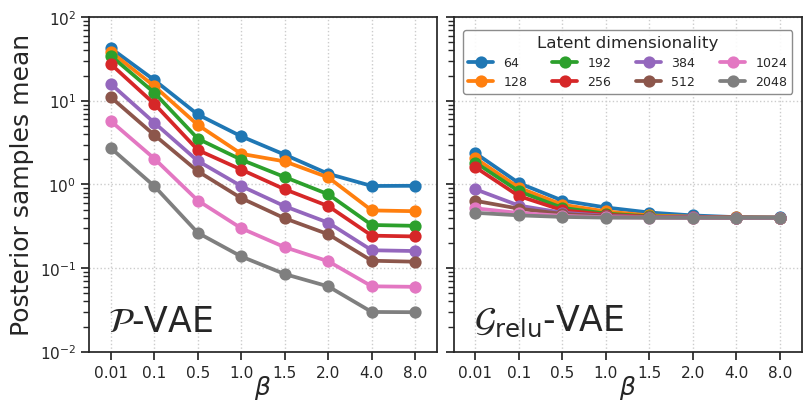

In [25]:
kws = dict(x='kl_beta', y='samples_mean', hue='n_latents', palette='tab10')

fig, axes = create_figure(1, 2, (8.0, 4.0), sharey='row')

ax = axes[0]
ax.set(yscale='log', ylim=(1e-2, 1e2))
ax.set_ylabel('Posterior samples mean', fontsize=18)

_df = df_metabolic_cost.loc[
    (df_metabolic_cost['n_latents'].isin(selected_k)) &
    (df_metabolic_cost['str_model'] == 'poisson+amort')
]
sns.pointplot(data=_df, ax=ax, legend=False, **kws)

ax = axes[1]
_df = df_metabolic_cost.loc[
    (df_metabolic_cost['n_latents'].isin(selected_k)) &
    (df_metabolic_cost['str_model'] == 'gaussian+relu+amort')
]
sns.pointplot(data=_df, ax=ax, legend=True, **kws)


# axes[0].set_title('Poisson', fontsize=15, y=1.02)
# axes[1].set_title('Gaussian + ReLU', fontsize=15, y=1.02)

axes[0].text(0.355, 0.04, r'$\mathcal{P}$-VAE', fontsize=25,
             transform=axes[0].transAxes, ha='right', va='bottom')
axes[1].text(0.49, 0.04, r'$\mathcal{G}_\mathrm{relu}$-VAE', fontsize=25,
             transform=axes[1].transAxes, ha='right', va='bottom')

for ax in axes.flat:
    ax.set_xlabel(r'$\beta$', fontsize=18, labelpad=-5)
    ax.grid()
    

# move_legend(ax, (1.3, 1.02))

sns.move_legend(
    axes[1],
    title='Latent dimensionality',
    loc='upper center',
    bbox_to_anchor=(0.5, 0.98),
    fontsize=9.0,
    title_fontsize=12,
    ncol=4,
    framealpha=0.9,
    edgecolor='gray',
)

fig.savefig(pjoin(fig_dir, 'posterior_sample_means.pdf'), bbox_inches='tight')
plt.show()

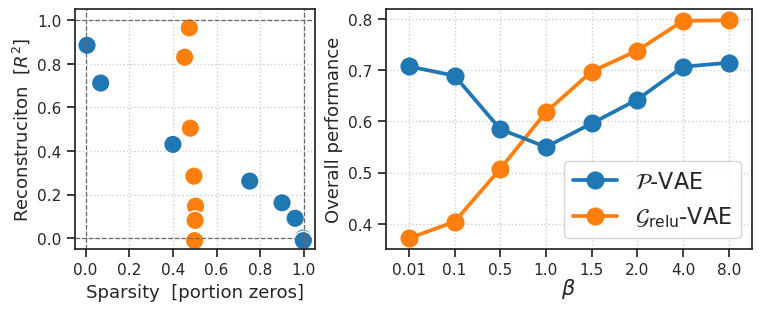

In [41]:
pal = {'poisson+amort': 'C0', 'gaussian+relu+amort': 'C1'}
_df = df_metabolic_cost.loc[df_metabolic_cost['n_latents'] == 512]

fig, axes = create_figure(1, 2, (7.5, 3.0), width_ratios=[1, 1.5])

ax = axes[0]
ax.axvline(0, color='dimgrey', ls='--', lw=0.9)
ax.axvline(1, color='dimgrey', ls='--', lw=0.9)
ax.axhline(1, color='dimgrey', ls='--', lw=0.9)
ax.axhline(0, color='dimgrey', ls='--', lw=0.9)
sns.scatterplot(
    data=_df,
    x='portion_zeros',
    y='r2',
    hue='str_model',
    palette=pal,
    legend=False,
    s=180,
    ax=ax,
)
ax.locator_params(axis='both', nbins=6)
ax.set(xlim=(-0.05, 1.05), ylim=(-0.05, 1.05))
ax_square(ax)
ax.set_ylabel('Reconstruciton  [$R^2$]', fontsize=13)
ax.set_xlabel('Sparsity  [portion zeros]', fontsize=13)

ax = axes[1]
sns.pointplot(
    data=_df,
    x='kl_beta',
    y='euc_dist',
    hue='str_model',
    palette=pal,
    markersize=11,
    ax=ax,
)
ax.set_xlabel(r"$\beta$", fontsize=15, labelpad=-0.5)
ax.set_ylabel('Overall performance', fontsize=13)

add_grid(axes)


# Fix legend labels and order
handles, labels = ax.get_legend_handles_labels()
label_map = {
    'poisson+amort': r'$\mathcal{P}$-VAE',
    'gaussian+relu+amort': r'$\mathcal{G}_\mathrm{relu}$-VAE',
}
# Build ordered handles/labels: Poisson first, then Gaussian+ReLU
desired_order = ['poisson+amort', 'gaussian+relu+amort']
new_handles = []
new_labels = []
for key in desired_order:
    idx = labels.index(key)
    new_handles.append(handles[idx])
    new_labels.append(label_map[key])

ax.legend(new_handles, new_labels, title='', fontsize=16)


fig.savefig(pjoin(fig_dir, 'rate_dist_tradeoff.pdf'), bbox_inches='tight')

plt.show()

## KL functions

In [267]:
def plot_vae_nonlinearities(figsize=(10, 5), sharey=False):
    fig, axes = create_figure(1, 2, figsize=figsize, sharey=sharey)
    
    # 1. Define the range for the log-residuals
    # Poisson: x = u = log(lambda_gain)
    # Gaussian: x = v = log(sigma^2_gain)  <-- log-variance
    x = np.linspace(-1.5, 1.5, 400)
    
    # 2. Define the functions
    
    # -- Poisson --
    # f(y) = y log y - y + 1
    # y = exp(x) -> f(x) = x * exp(x) - exp(x) + 1
    y_pois = np.exp(x)
    f_val = y_pois * np.log(y_pois) - y_pois + 1
    
    # -- Gaussian --
    # g(y) = y - 1 - log(y)   <-- New definition
    # y = exp(x) (variance gain)
    y_gauss = np.exp(x)
    g_val = y_gauss - 1 - np.log(y_gauss) # Becomes: exp(x) - 1 - x
    
    # 3. Define the Quadratic Approximations
    
    # Poisson approx: 0.5 * u^2 (f''(1) = 1)
    f_approx = 0.5 * x**2
    
    # Gaussian approx: 0.5 * v^2 (g''(1) = 1)
    # Expansion of (e^x - 1 - x) is 0.5 * x^2
    g_approx = 0.5 * x**2

    # 4. Plotting
    
    # -- Plot Poisson --
    ax = axes[0]
    ax.plot(x, f_val, label=r'True:   $f\,(e^{\delta u})$', linewidth=3.0, color='C0')
    ax.plot(x, f_approx, label=r'Approx:   $0.5 \, \delta u^2$', linestyle='--', linewidth=2.5, color='black', alpha=0.8)
    
    ax.set_xlabel(r'log-rate:   $\delta u \,=\, \log \delta \lambda$', fontsize=15)
    ax.set_ylabel(r'Cost contribution   $f(\delta \lambda)$', fontsize=15)

    # -- Plot Gaussian --
    ax = axes[1]
    # Note: Argument to g is variance gain (exp(v))
    ax.plot(x, g_val, label=r'True:   $g\,(e^{\delta v})$', linewidth=3.0, color='C1')
    ax.plot(x, g_approx, label=r'Approx:   $0.5 \, \delta v^2$', linestyle='--', linewidth=2.5, color='black', alpha=0.8)
    
    ax.set_xlabel(r'log-var:   $\delta v \,=\, \log \delta \sigma^2$', fontsize=15)
    ax.set_ylabel(r'Cost contribution   $g(\delta \sigma^2)$', fontsize=15)

    for ax in axes.flat:
        ax.legend(fontsize=15, loc='upper left')
        ax.axhline(0, ls=':', color='dimgrey', zorder=-1)
        ax.grid()
        
    axes[0].text(0.62, 0.45, r'$\mathcal{P}$-VAE', fontsize=20, color='C0',
                 transform=axes[0].transAxes, ha='right', va='bottom')
    axes[1].text(0.62, 0.45, r'$\mathcal{G}$-VAE', fontsize=20, color='C1',
                 transform=axes[1].transAxes, ha='right', va='bottom')

    plt.show()
    return fig

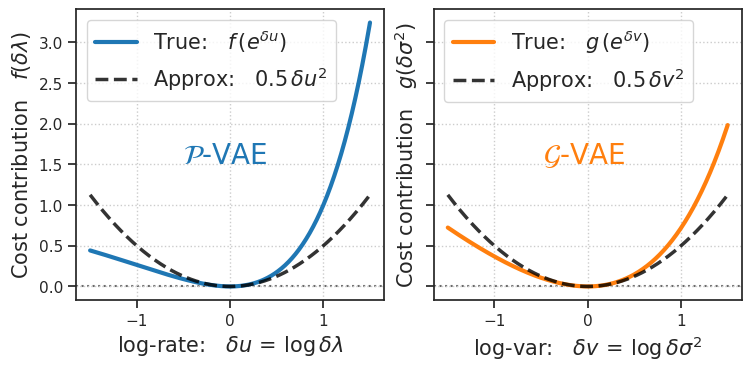

In [269]:
fig = plot_vae_nonlinearities((7.4, 3.6), True)

# fig.savefig(pjoin(fig_dir, 'kl_f_g.pdf'), bbox_inches='tight')

## Gaussian rectified moments

In [391]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def tonp(x):
    return x.detach().cpu().numpy()

# Re-implementing the verified PyTorch logic here for the plot
def get_rectified_moments(mu, sigma):
    """
    Computes analytical mean and variance for Rectified Gaussian: max(0, N(mu, sigma^2))
    """
    # Standardize
    alpha = mu / sigma
    
    # PDF and CDF of standard normal
    pdf = (1.0 / np.sqrt(2 * np.pi)) * torch.exp(-0.5 * alpha**2)
    cdf = 0.5 * (1 + torch.erf(alpha / np.sqrt(2)))
    
    # First Moment: E[y]
    # Formula: mu * Phi(alpha) + sigma * phi(alpha)
    mean = mu * cdf + sigma * pdf
    
    # Second Moment: E[y^2]
    # Formula: (mu^2 + sigma^2) * Phi(alpha) + mu * sigma * phi(alpha)
    second_moment = (mu**2 + sigma**2) * cdf + mu * sigma * pdf
    
    # Variance: E[y^2] - (E[y])^2
    var = second_moment - mean**2
    
    return mean, var

def plot_rectified_moments(colors='Spectral_r', lim=5, figsize=(7, 3.5)):
    # 1. Setup Data
    mus = torch.linspace(-lim, lim, 1000) 
    sigmas = [1.0, 1.5, 2.0, 2.5] 
    
    # 2. Setup Plot
    fig, axes = create_figure(1, 2, figsize=figsize)
    
    # 3. Handle Colors (Colormap string vs List of colors)
    color_list = []
    if isinstance(colors, str):
        # It's a colormap name -> Generate list using the clip range
        cmap = plt.get_cmap(colors)
        c_min, c_max = 0.2, 0.8
        for i in range(len(sigmas)):
            fraction = i / (len(sigmas) - 1) if len(sigmas) > 1 else 0.5
            color_idx = c_min + (c_max - c_min) * fraction
            color_list.append(cmap(color_idx))
    else:
        # It's a specific list -> Use directly
        color_list = colors

    # 4. Plot the Canonical References
    x_ref = np.linspace(-lim, lim, 1000)
    
    # Reference for Mean: Softplus
    y_softplus = np.log(1 + np.exp(x_ref))
    axes[0].plot(x_ref, y_softplus, color='k', linestyle='--', linewidth=1.0, 
                 label='softplus', zorder=5, alpha=1.0)

    # Reference for Variance: Sigmoid
    y_sigmoid = 1 / (1 + np.exp(-x_ref))
    axes[1].plot(x_ref, y_sigmoid, color='k', linestyle='--', linewidth=1.0, 
                 label='sigmoid', zorder=5, alpha=1.0)

    # 5. Iterate and Plot Sigmas
    for i, s_val in enumerate(sigmas):
        # Create sigma tensor
        sigma_tensor = torch.full_like(mus, s_val)
        
        # Calculate moments
        mean_out, var_out = get_rectified_moments(mus, sigma_tensor)
        
        # Convert to numpy
        mu_np = tonp(mus)
        mean_np = tonp(mean_out)
        var_np = tonp(var_out)
        
        # Select color (cycle if list is shorter than sigmas)
        color = color_list[i % len(color_list)]
        
        label = f'$\sigma={s_val}$'
        
        # Plot
        axes[0].plot(mu_np, mean_np, color=color, label=label, linewidth=2.5)
        axes[1].plot(mu_np, var_np, color=color, label=label, linewidth=2.5)

    # 6. Formatting
    axes[0].set_ylabel(r"$\mathrm{Mean}_q\;[\,\mathrm{relu}(z)\,]$", fontsize=15)
    axes[1].set_ylabel(r"$\mathrm{Var}_q\;[\,\mathrm{relu}(z)\,]$", fontsize=15)
    
    for ax in axes.flat:
        ax.set_xlabel(r"$\mu$", fontsize=18)
        ax.legend(fontsize=13.3)
        ax.grid(alpha=0.5)

    plt.show()
    return fig

In [408]:
cmap = sns.color_palette('Spectral_r', n_colors=18)
cmap

[(0.2806612841214917, 0.423760092272203, 0.6892733564013841),
 (0.2000768935024991, 0.5377931564782776, 0.7393310265282583),
 (0.31203383314109967, 0.6626682045367167, 0.6876585928489043),
 (0.4212226066897348, 0.7690888119953864, 0.6467512495194156),
 (0.5697808535178779, 0.8272202998846598, 0.6445982314494426),
 (0.7023452518262208, 0.8795847750865052, 0.6366782006920415),
 (0.829373317954633, 0.9312572087658594, 0.6108419838523644),
 (0.9211841599384853, 0.9684736639753941, 0.6260668973471742),
 (0.9750096116878124, 0.9900038446751249, 0.7100346020761246),
 (0.9990003844675125, 0.9690119184928874, 0.697039600153787),
 (0.9968473663975395, 0.9022683583237218, 0.5850826605151866),
 (0.9948481353325644, 0.8169165705497885, 0.49342560553633213),
 (0.9926951172625913, 0.7092656670511341, 0.4029988465974625),
 (0.9790080738177624, 0.5873894655901576, 0.336562860438293),
 (0.9596309111880047, 0.44744329104190694, 0.27197231833910035),
 (0.9044213763936948, 0.34794309880815066, 0.28304498269896194),
 (0.8376778162245291, 0.2467512495194156, 0.308881199538639),
 (0.7295655517108804, 0.12587466359092658, 0.2848135332564399)]

In [436]:
colors = [cmap[i] for i in [2, 5, -7, -4]]

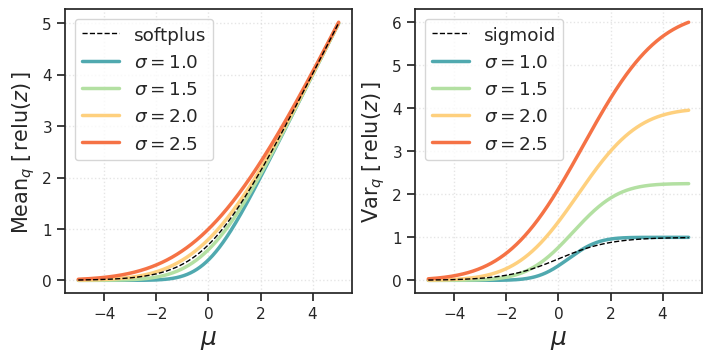

In [438]:
fig = plot_rectified_moments(colors)
# fig.savefig(pjoin(fig_dir, 'rectified_moments.pdf'), bbox_inches='tight')